
# Comparación de inversiones de perturbación Whittaker BG12976567

Este notebook compara tres casos guardados en los HDF5 de inversión de perturbación:

1. **Seed inicial de la primera corrida** (`15517278`, grupo `initial/`).
2. **Reconstrucción/best de la primera corrida** (`15517278`, grupo `reconstruction/`).
3. **Reconstrucción/best de la segunda corrida** (`15572093`, grupo `reconstruction/`).

La comparación se hace contra los **datos reales corregidos** (`target_A_corr`, `target_phi_corr`) almacenados en los HDF5. Las métricas se recalculan dentro del notebook para evitar depender ciegamente de los valores guardados.

Las leyendas de las curvas incluyen:

- `chi2_norm_A`
- `chi2_norm_phi`
- `chi2_norm_total`
- `RMSE` del canal graficado


In [1]:

begin
    using HDF5
    using Dates
    using Statistics
    using DataFrames
    using CairoMakie
    using Printf

    CairoMakie.activate!()

    OUTDIR = joinpath(pwd(), "comparacion_perturbacion_whittaker_restart15572093")
    mkpath(OUTDIR)

    println("Directorio de salida:")
    println(OUTDIR)
end


Directorio de salida:
/home/jp/basefolder_JP/comparacion_perturbacion_whittaker_restart15572093



## 1. Rutas de entrada

El notebook busca los HDF5 en este orden:

1. ruta indicada por variable de entorno;
2. carpeta actual;
3. `/mnt/data`.


In [2]:

begin
    FIRST_H5_NAME = "new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_rel10_results_15517278.h5"
    SECOND_H5_NAME = "new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_restart_from15517278_rel10_z0wide20_results_15572093.h5"

    function find_existing_file(name_or_path::AbstractString)
        candidates = String[
            name_or_path,
            joinpath(pwd(), name_or_path),
            joinpath("/mnt/data", basename(name_or_path)),
        ]

        for p in unique(candidates)
            if isfile(p)
                return abspath(p)
            end
        end

        error("No encontré el archivo: $(name_or_path)")
    end

    FIRST_H5 = find_existing_file(get(ENV, "FIRST_RESULTS_H5", FIRST_H5_NAME))
    SECOND_H5 = find_existing_file(get(ENV, "SECOND_RESULTS_H5", SECOND_H5_NAME))

    println("FIRST_H5  = ", FIRST_H5)
    println("SECOND_H5 = ", SECOND_H5)
end


FIRST_H5  = /home/jp/basefolder_JP/new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_rel10_results_15517278.h5
SECOND_H5 = /home/jp/basefolder_JP/new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_restart_from15517278_rel10_z0wide20_results_15572093.h5



## 2. Funciones auxiliares


In [3]:

begin
    function h5attr(path::AbstractString, name::AbstractString; default = missing)
        h5open(path, "r") do f
            attrs = HDF5.attributes(f)
            if haskey(attrs, name)
                return read(attrs[name])
            else
                return default
            end
        end
    end

    function clean_h5_string(x)
        if x === missing
            return missing
        elseif x isa AbstractString
            return replace(String(x), "\0" => "")
        elseif x isa Vector{UInt8}
            return replace(String(x), "\0" => "")
        elseif x isa Array{UInt8}
            return replace(String(vec(x)), "\0" => "")
        else
            return x
        end
    end

    function read_vector(path::AbstractString, dset::AbstractString)
        return Vector{Float64}(h5read(path, dset))
    end

    function read_scalar_float(path::AbstractString, dset::AbstractString)
        x = h5read(path, dset)
        if x isa Number
            return Float64(x)
        else
            return Float64(vec(x)[1])
        end
    end

    function normalized_chi2(model::AbstractVector, target::AbstractVector)
        denom = sum((target .- mean(target)).^2)
        denom == 0 && error("Target con varianza cero; no puedo normalizar chi2.")
        return sum((model .- target).^2) / denom
    end

    rmse(model::AbstractVector, target::AbstractVector) = sqrt(mean((model .- target).^2))

    fmt(x; digits = 4) = @sprintf("%.*f", digits, Float64(x))

    function hhmm_ticks(time_utc::Vector{DateTime}; step = 2)
        idx = collect(1:step:length(time_utc))
        idx[end] != length(time_utc) && push!(idx, length(time_utc))
        t0 = datetime2unix(time_utc[1])
        t_min = [(datetime2unix(t) - t0) / 60 for t in time_utc]
        return (t_min[idx], Dates.format.(time_utc[idx], "HH:MM"))
    end
end


hhmm_ticks (generic function with 1 method)


## 3. Carga y auditoría básica de los HDF5


In [4]:

begin
    # Tiempo y targets. Se toma el target del primer HDF5 y se verifica contra el segundo.
    timestamps1 = read_vector(FIRST_H5, "timestamps")
    timestamps2 = read_vector(SECOND_H5, "timestamps")

    target_A_corr_1 = read_vector(FIRST_H5, "target_A_corr")
    target_phi_corr_1 = read_vector(FIRST_H5, "target_phi_corr")
    target_A_corr_2 = read_vector(SECOND_H5, "target_A_corr")
    target_phi_corr_2 = read_vector(SECOND_H5, "target_phi_corr")

    @assert length(timestamps1) == length(timestamps2) "Los HDF5 no tienen el mismo número de tiempos."
    @assert maximum(abs.(timestamps1 .- timestamps2)) < 1e-6 "Los timestamps de primera y segunda corrida no coinciden."
    @assert maximum(abs.(target_A_corr_1 .- target_A_corr_2)) < 1e-8 "target_A_corr no coincide entre corridas."
    @assert maximum(abs.(target_phi_corr_1 .- target_phi_corr_2)) < 1e-8 "target_phi_corr no coincide entre corridas."

    timestamps = timestamps1
    time_utc = unix2datetime.(round.(Int, timestamps))
    t_min = (timestamps .- timestamps[1]) ./ 60.0

    target_A_corr = target_A_corr_1
    target_phi_corr = target_phi_corr_1

    println("Número de puntos: ", length(timestamps))
    println("Inicio UTC: ", first(time_utc))
    println("Fin UTC:    ", last(time_utc))
    println("Paso típico [min]: ", median(diff(t_min)))

    attrs_df = DataFrame(
        campo = [
            "background_source_h5",
            "separation_source_h5",
            "target_source",
            "t_pk_fixed_utc",
            "amp_offset_db_used",
            "phi_offset_deg_used",
            "bounds_type primera",
            "bounds_type segunda",
            "previous_results_h5 segunda",
        ],
        valor = [
            string(clean_h5_string(h5attr(FIRST_H5, "background_source_h5"))),
            string(clean_h5_string(h5attr(FIRST_H5, "separation_source_h5"))),
            string(clean_h5_string(h5attr(FIRST_H5, "target_source"))),
            string(clean_h5_string(h5attr(FIRST_H5, "t_pk_fixed_utc"))),
            string(h5attr(FIRST_H5, "amp_offset_db_used")),
            string(h5attr(FIRST_H5, "phi_offset_deg_used")),
            string(clean_h5_string(h5attr(FIRST_H5, "bounds_type"))),
            string(clean_h5_string(h5attr(SECOND_H5, "bounds_type"))),
            string(clean_h5_string(h5attr(SECOND_H5, "previous_results_h5"; default=""))),
        ],
    )

    display(attrs_df)
end


Número de puntos: 17
Inicio UTC: 2008-03-25T18:00:00
Fin UTC:    2008-03-25T22:00:00
Paso típico [min]: 15.0


Row,campo,valor
,String,String
1,background_source_h5,new-real-background-inversion_from_sep_16_22_restart15_results_12976567.h5
2,separation_source_h5,real_whittaker_selected_background_16_22_for_inversion.h5
3,target_source,"A_real, phi_real from separation H5"
4,t_pk_fixed_utc,2008-03-25T19:00:00+00:00
5,amp_offset_db_used,19.0
6,phi_offset_deg_used,-210.0
7,bounds_type primera,relative_to_initial_free_params
8,bounds_type segunda,directed_restart_relative_to_previous_reconstruction_free_params
9,previous_results_h5 segunda,new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_rel10_results_15517278.h5



## 4. Cargar los tres casos comparados

Casos comparados:

- `seed inicial 1ra`: grupo `initial/` del HDF5 `15517278`.
- `best 1ra`: grupo `reconstruction/` del HDF5 `15517278`.
- `best 2da`: grupo `reconstruction/` del HDF5 `15572093`.


In [5]:

begin
    cases = [
        (
            name = "seed inicial 1ra",
            short = "seed1",
            path = FIRST_H5,
            group = "initial",
            A = read_vector(FIRST_H5, "initial/A_model"),
            phi = read_vector(FIRST_H5, "initial/phi_model"),
            free_params = read_vector(FIRST_H5, "initial/free_params"),
            full_params = read_vector(FIRST_H5, "initial/full_params"),
        ),
        (
            name = "best 1ra",
            short = "best1",
            path = FIRST_H5,
            group = "reconstruction",
            A = read_vector(FIRST_H5, "reconstruction/A_model"),
            phi = read_vector(FIRST_H5, "reconstruction/phi_model"),
            free_params = read_vector(FIRST_H5, "reconstruction/free_params"),
            full_params = read_vector(FIRST_H5, "reconstruction/full_params"),
        ),
        (
            name = "best 2da",
            short = "best2",
            path = SECOND_H5,
            group = "reconstruction",
            A = read_vector(SECOND_H5, "reconstruction/A_model"),
            phi = read_vector(SECOND_H5, "reconstruction/phi_model"),
            free_params = read_vector(SECOND_H5, "reconstruction/free_params"),
            full_params = read_vector(SECOND_H5, "reconstruction/full_params"),
        ),
    ]

    println("Casos cargados:")
    for c in cases
        println("  - ", c.name, "  N=", length(c.A))
    end

    # Auditoría del restart: seed de segunda corrida vs best de primera.
    second_initial_free = read_vector(SECOND_H5, "initial/free_params")
    first_best_free = read_vector(FIRST_H5, "reconstruction/free_params")
    maxdiff_restart_seed = maximum(abs.(second_initial_free .- first_best_free))

    println("\nmax |segunda/initial/free_params - primera/reconstruction/free_params| = ", maxdiff_restart_seed)
end


Casos cargados:
  - seed inicial 1ra  N=17
  - best 1ra  N=17
  - best 2da  N=17

max |segunda/initial/free_params - primera/reconstruction/free_params| = 0.0



## 5. Métricas recalculadas contra datos reales corregidos


In [6]:

begin
    metrics = DataFrame(
        case = String[],
        chi2_norm_A = Float64[],
        chi2_norm_phi = Float64[],
        chi2_norm_total = Float64[],
        RMSE_A_dB = Float64[],
        RMSE_phi_deg = Float64[],
    )

    for c in cases
        chiA = normalized_chi2(c.A, target_A_corr)
        chip = normalized_chi2(c.phi, target_phi_corr)
        push!(metrics, (
            c.name,
            chiA,
            chip,
            chiA + chip,
            rmse(c.A, target_A_corr),
            rmse(c.phi, target_phi_corr),
        ))
    end

    display(metrics)

    seed_total = metrics[metrics.case .== "seed inicial 1ra", :chi2_norm_total][1]
    best1_total = metrics[metrics.case .== "best 1ra", :chi2_norm_total][1]
    best2_total = metrics[metrics.case .== "best 2da", :chi2_norm_total][1]

    improvements = DataFrame(
        comparison = [
            "best 1ra vs seed inicial 1ra",
            "best 2da vs best 1ra",
            "best 2da vs seed inicial 1ra",
        ],
        mejora_chi2_total_pct = [
            100 * (seed_total - best1_total) / seed_total,
            100 * (best1_total - best2_total) / best1_total,
            100 * (seed_total - best2_total) / seed_total,
        ],
    )

    display(improvements)
end


Row,case,chi2_norm_A,chi2_norm_phi,chi2_norm_total,RMSE_A_dB,RMSE_phi_deg
,String,Float64,Float64,Float64,Float64,Float64
1,seed inicial 1ra,0.287668,0.30898,0.596649,1.28635,19.4337
2,best 1ra,0.190443,0.131701,0.322144,1.04663,12.6878
3,best 2da,0.180888,0.119095,0.299983,1.02004,12.0652


Row,comparison,mejora_chi2_total_pct
,String,Float64
1,best 1ra vs seed inicial 1ra,46.0077
2,best 2da vs best 1ra,6.87921
3,best 2da vs seed inicial 1ra,49.722



## 6. Construir DataFrame combinado para gráficos


In [7]:

begin
    df = DataFrame(
        time_utc = time_utc,
        t_min = t_min,
        target_A_corr = target_A_corr,
        target_phi_corr = target_phi_corr,
    )

    for c in cases
        s = c.short
        df[!, Symbol("A_" * s)] = c.A
        df[!, Symbol("phi_" * s)] = c.phi
        df[!, Symbol("res_A_" * s)] = c.A .- target_A_corr
        df[!, Symbol("res_phi_" * s)] = c.phi .- target_phi_corr
    end

    first(df, 5) |> display
end


Row,time_utc,t_min,target_A_corr,target_phi_corr,A_seed1,phi_seed1,res_A_seed1,res_phi_seed1,A_best1,phi_best1,res_A_best1,res_phi_best1,A_best2,phi_best2,res_A_best2,res_phi_best2
,DateTime,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,2008-03-25T18:00:00,0.0,57.35,349.895,55.3803,357.745,-1.9697,7.85044,55.3835,357.744,-1.96654,7.84942,55.3784,357.745,-1.97158,7.84964
2,2008-03-25T18:15:00,15.0,57.24,348.535,55.3828,356.54,-1.85716,8.00473,55.3861,356.483,-1.85392,7.94809,55.3838,356.487,-1.85618,7.95201
3,2008-03-25T18:30:00,30.0,57.18,348.24,55.3978,354.846,-1.78219,6.60578,55.3998,354.845,-1.78018,6.60482,55.3973,354.822,-1.78268,6.58175
4,2008-03-25T18:45:00,45.0,57.715,368.055,55.4662,353.827,-2.24878,-14.2276,55.5618,355.296,-2.1532,-12.7594,55.7053,357.425,-2.00968,-10.6303
5,2008-03-25T19:00:00,60.0,60.65,437.905,58.233,403.432,-2.41696,-34.4733,59.6262,434.411,-1.0238,-3.49394,59.9323,443.178,-0.717736,5.27285



## 7. Funciones de etiquetas para las leyendas


In [8]:

begin
    function metric_row(case_name::AbstractString)
        i = findfirst(==(case_name), metrics.case)
        i === nothing && error("No encontré métricas para caso: $(case_name)")
        return metrics[i, :]
    end

    function curve_label(case_name::AbstractString, channel::Symbol)
        r = metric_row(case_name)
        chiA = r.chi2_norm_A
        chip = r.chi2_norm_phi
        chit = r.chi2_norm_total

        if channel === :A
            rm = r.RMSE_A_dB
            return "$(case_name) (chi2_norm_A=$(fmt(chiA)), chi2_norm_phi=$(fmt(chip)), chi2_norm_total=$(fmt(chit)), RMSE=$(fmt(rm, digits=3)) dB)"
        elseif channel === :phi
            rm = r.RMSE_phi_deg
            return "$(case_name) (chi2_norm_A=$(fmt(chiA)), chi2_norm_phi=$(fmt(chip)), chi2_norm_total=$(fmt(chit)), RMSE=$(fmt(rm, digits=3))°)"
        else
            error("Canal no reconocido: $(channel)")
        end
    end

    xt = hhmm_ticks(time_utc; step = 2)

    # t_pk fijo correcto, guardado como atributo UTC en el HDF5.
    t_pk_fixed_utc_attr = clean_h5_string(h5attr(FIRST_H5, "t_pk_fixed_utc"; default = ""))
    t_pk_plot_min = NaN
    t_pk_label = "t_pk fijo"

    if t_pk_fixed_utc_attr !== missing && !isempty(String(t_pk_fixed_utc_attr))
        # Formato esperado: 2008-03-25T19:00:00+00:00
        tpk_str = replace(String(t_pk_fixed_utc_attr), "+00:00" => "")
        tpk_dt = DateTime(tpk_str)
        t_pk_plot_min = (datetime2unix(tpk_dt) - timestamps[1]) / 60
        t_pk_label = "t_pk fijo = " * Dates.format(tpk_dt, "HH:MM") * " UTC"
    else
        t_pk_s = read_scalar_float(FIRST_H5, "fixed/t_pk_s")
        t0_model = DateTime(2008, 3, 25, 18, 30, 0)
        tpk_dt = t0_model + Second(round(Int, t_pk_s))
        t_pk_plot_min = (datetime2unix(tpk_dt) - timestamps[1]) / 60
        t_pk_label = "t_pk fijo = " * Dates.format(tpk_dt, "HH:MM") * " UTC"
    end

    println(t_pk_label, " → t_min = ", t_pk_plot_min)
end


t_pk fijo = 19:00 UTC → t_min = 60.0



## 8. Gráfico principal: series de tiempo

Las curvas comparan datos reales corregidos contra:

- seed inicial de la primera corrida;
- best de la primera corrida;
- best de la segunda corrida.


Figura guardada en: /home/jp/basefolder_JP/comparacion_perturbacion_whittaker_restart15572093/series_tiempo_comparacion_seed1_best1_best2.png


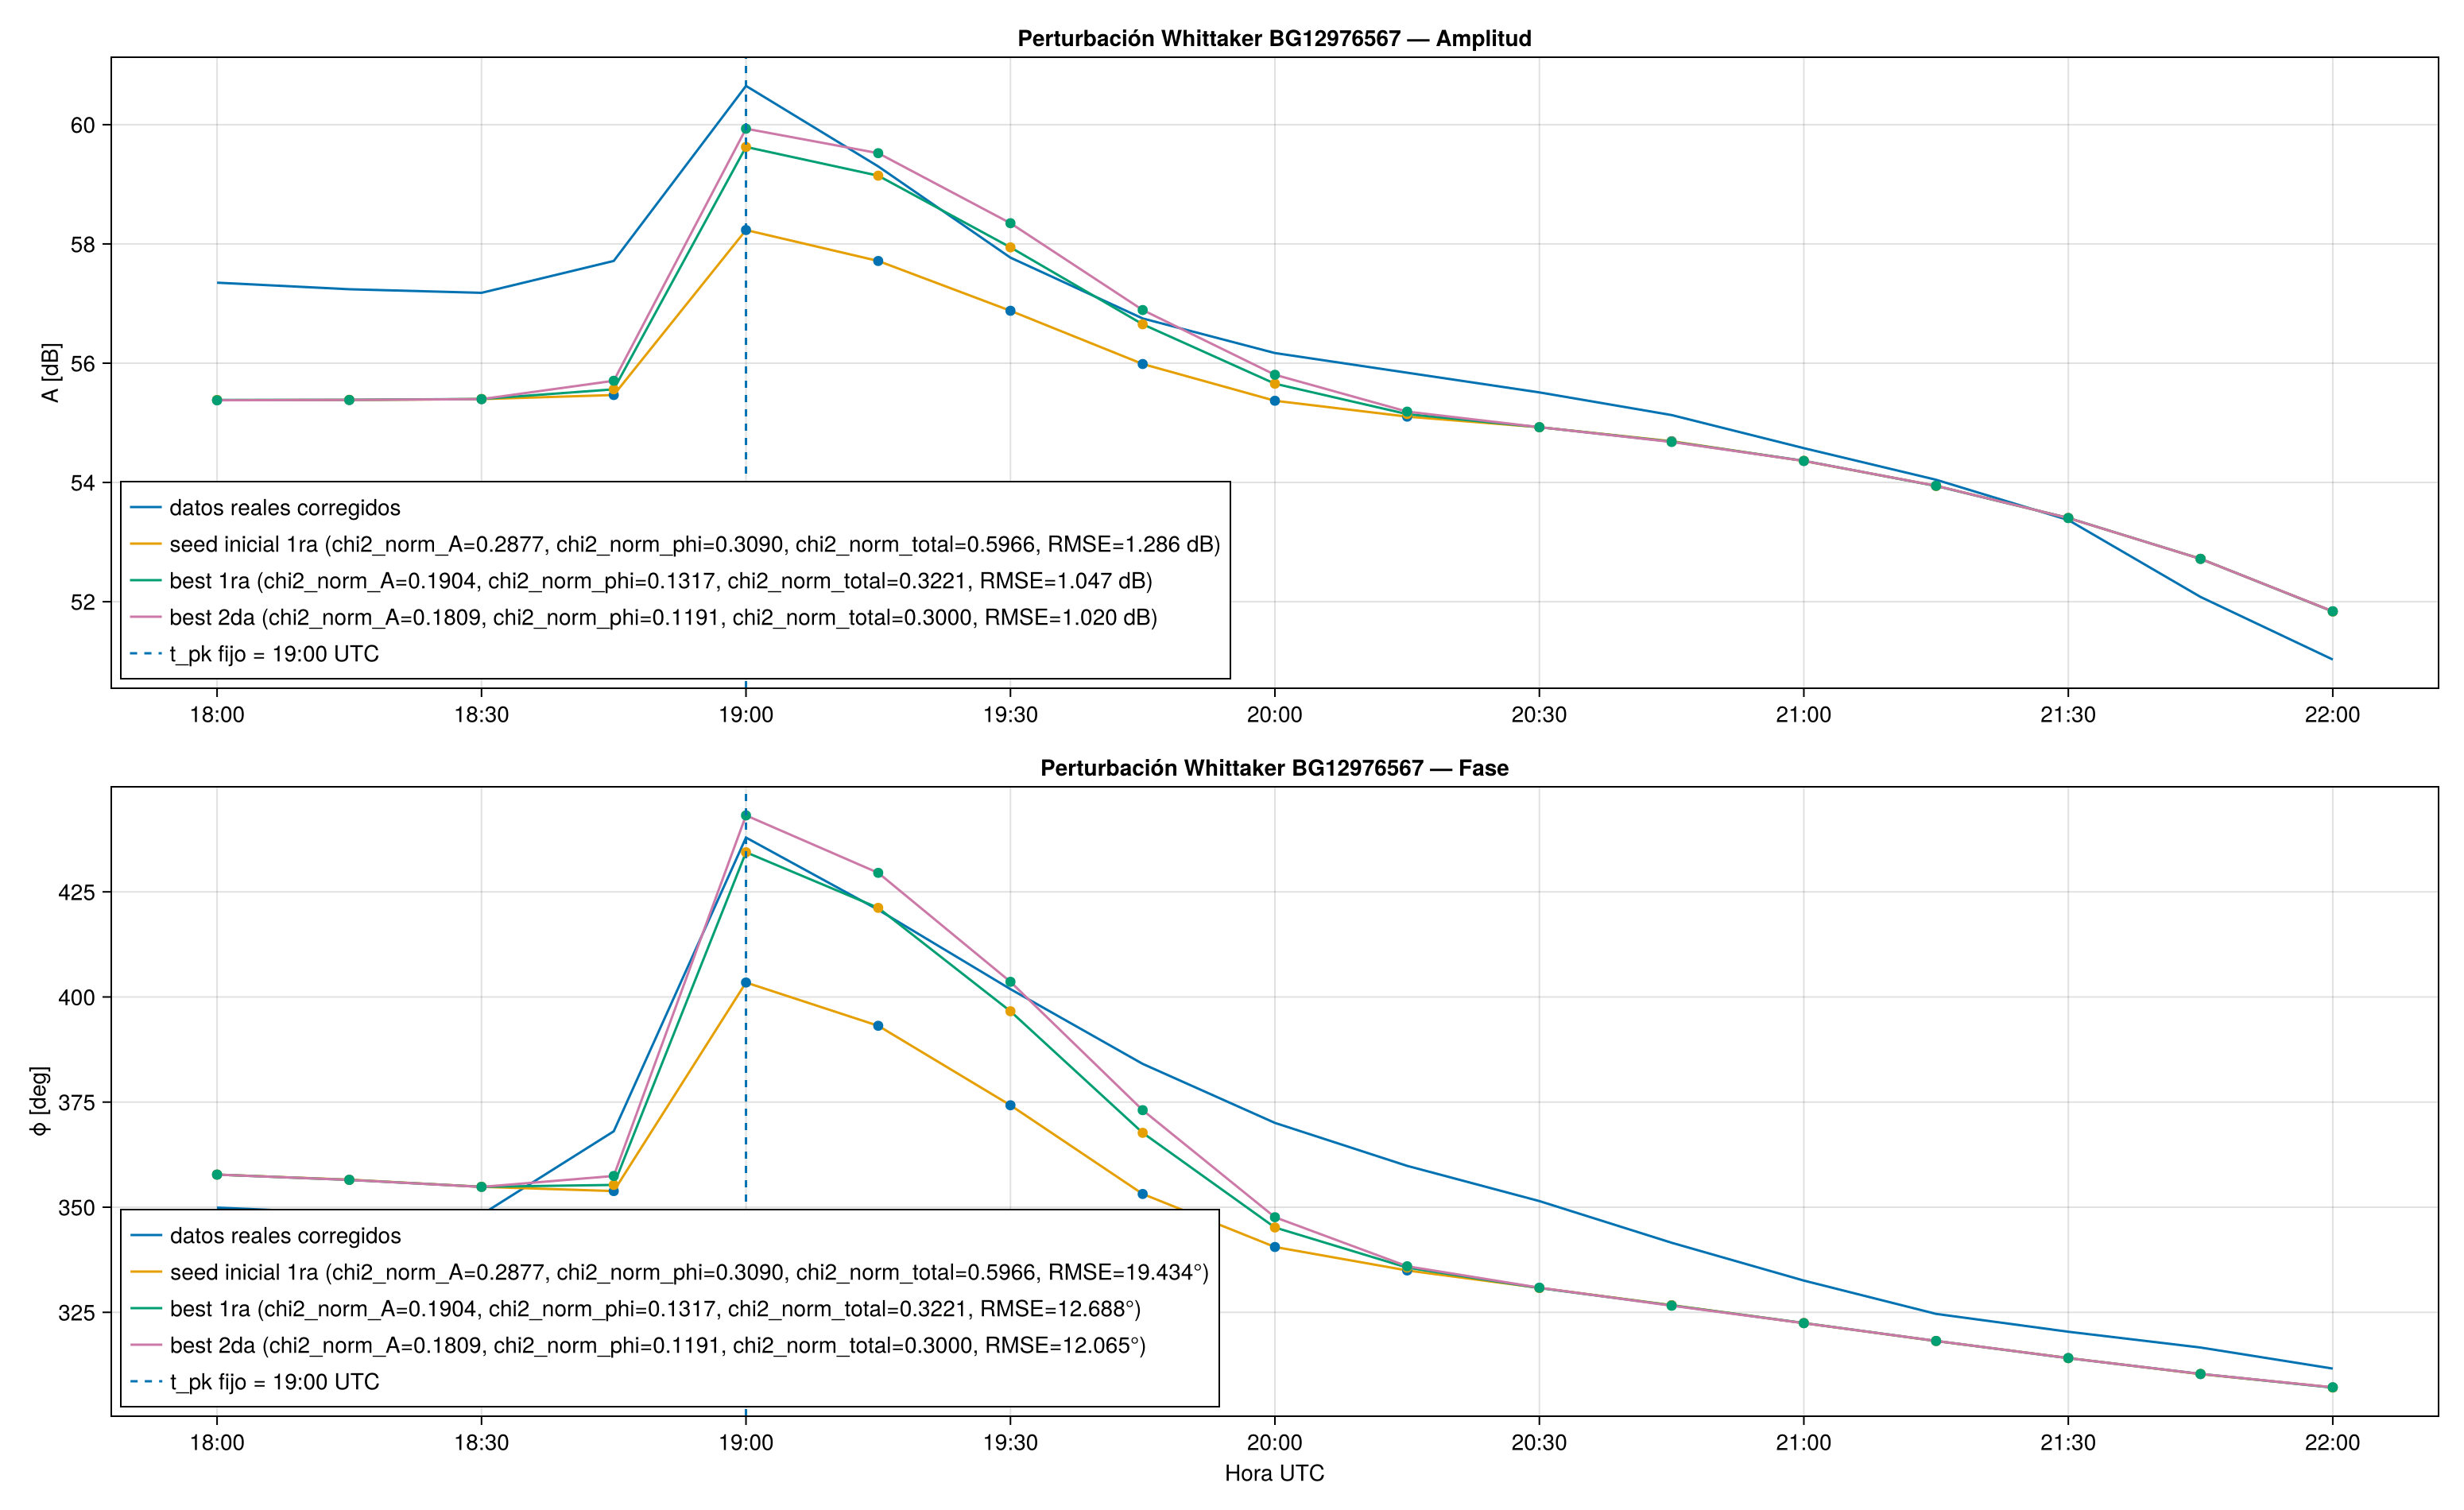

In [9]:

begin
    fig_series = Figure(size = (1550, 950))

    axA = Axis(
        fig_series[1, 1],
        title = "Perturbación Whittaker BG12976567 — Amplitud",
        ylabel = "A [dB]",
        xticks = xt,
    )

    lines!(axA, df.t_min, df.target_A_corr, label = "datos reales corregidos")

    lines!(axA, df.t_min, df.A_seed1, label = curve_label("seed inicial 1ra", :A))
    scatter!(axA, df.t_min, df.A_seed1)

    lines!(axA, df.t_min, df.A_best1, label = curve_label("best 1ra", :A))
    scatter!(axA, df.t_min, df.A_best1)

    lines!(axA, df.t_min, df.A_best2, label = curve_label("best 2da", :A))
    scatter!(axA, df.t_min, df.A_best2)

    vlines!(axA, [t_pk_plot_min], linestyle = :dash, label = t_pk_label)
    axislegend(axA, position = :lb, framevisible = true, nbanks = 1)

    axP = Axis(
        fig_series[2, 1],
        title = "Perturbación Whittaker BG12976567 — Fase",
        xlabel = "Hora UTC",
        ylabel = "ϕ [deg]",
        xticks = xt,
    )

    lines!(axP, df.t_min, df.target_phi_corr, label = "datos reales corregidos")

    lines!(axP, df.t_min, df.phi_seed1, label = curve_label("seed inicial 1ra", :phi))
    scatter!(axP, df.t_min, df.phi_seed1)

    lines!(axP, df.t_min, df.phi_best1, label = curve_label("best 1ra", :phi))
    scatter!(axP, df.t_min, df.phi_best1)

    lines!(axP, df.t_min, df.phi_best2, label = curve_label("best 2da", :phi))
    scatter!(axP, df.t_min, df.phi_best2)

    vlines!(axP, [t_pk_plot_min], linestyle = :dash, label = t_pk_label)
    axislegend(axP, position = :lb, framevisible = true, nbanks = 1)

    linkxaxes!(axA, axP)

    path_series = joinpath(OUTDIR, "series_tiempo_comparacion_seed1_best1_best2.png")
    save(path_series, fig_series)
    println("Figura guardada en: ", path_series)

    fig_series
end


Figura guardada en: /home/jp/basefolder_JP/comparacion_perturbacion_whittaker_restart15572093/series_tiempo_comparacion_seed1_best1_best2.png


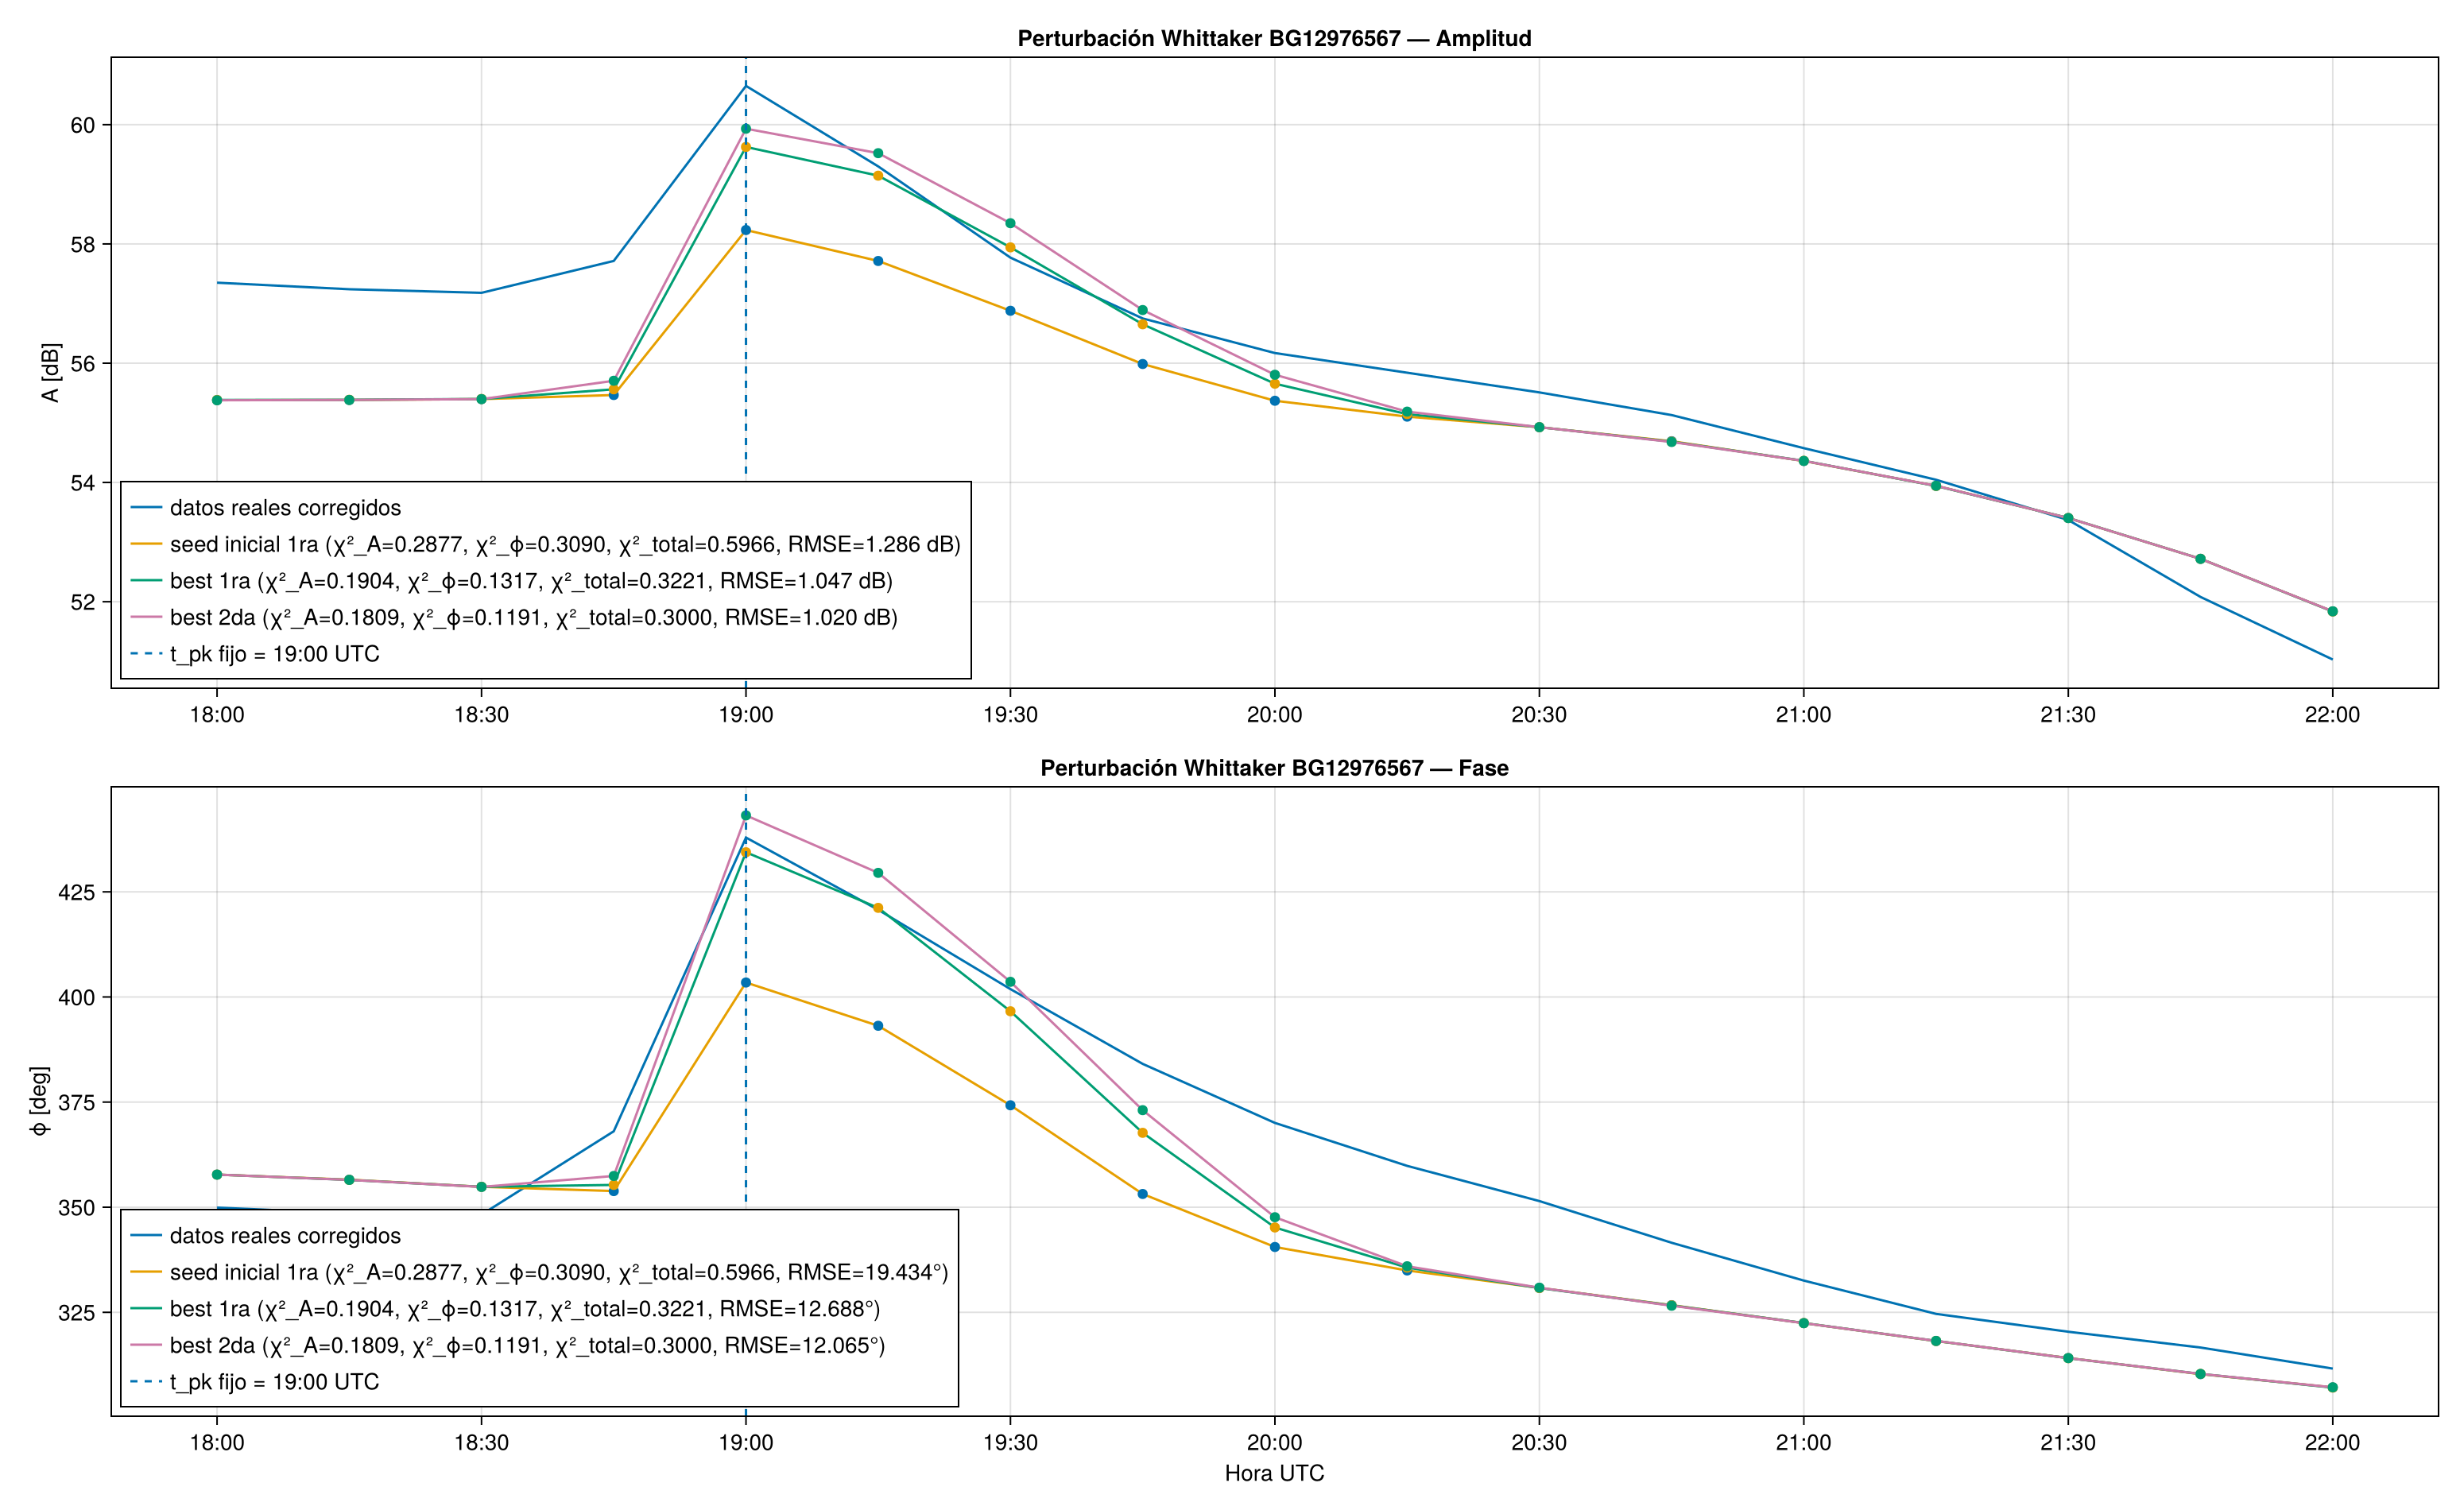

In [15]:
begin
    # ------------------------------------------------------------------------
    # Métricas para armar leyendas manuales con símbolos
    # ------------------------------------------------------------------------
    i_seed1 = findfirst(==("seed inicial 1ra"), metrics.case)
    i_best1 = findfirst(==("best 1ra"), metrics.case)
    i_best2 = findfirst(==("best 2da"), metrics.case)

    i_seed1 === nothing && error("No encontré métricas para seed inicial 1ra")
    i_best1 === nothing && error("No encontré métricas para best 1ra")
    i_best2 === nothing && error("No encontré métricas para best 2da")

    label_seed1_A =
        "seed inicial 1ra " *
        "(χ²_A=$(fmt(metrics[i_seed1, :chi2_norm_A])), " *
        "χ²_ϕ=$(fmt(metrics[i_seed1, :chi2_norm_phi])), " *
        "χ²_total=$(fmt(metrics[i_seed1, :chi2_norm_total])), " *
        "RMSE=$(fmt(metrics[i_seed1, :RMSE_A_dB], digits=3)) dB)"

    label_best1_A =
        "best 1ra " *
        "(χ²_A=$(fmt(metrics[i_best1, :chi2_norm_A])), " *
        "χ²_ϕ=$(fmt(metrics[i_best1, :chi2_norm_phi])), " *
        "χ²_total=$(fmt(metrics[i_best1, :chi2_norm_total])), " *
        "RMSE=$(fmt(metrics[i_best1, :RMSE_A_dB], digits=3)) dB)"

    label_best2_A =
        "best 2da " *
        "(χ²_A=$(fmt(metrics[i_best2, :chi2_norm_A])), " *
        "χ²_ϕ=$(fmt(metrics[i_best2, :chi2_norm_phi])), " *
        "χ²_total=$(fmt(metrics[i_best2, :chi2_norm_total])), " *
        "RMSE=$(fmt(metrics[i_best2, :RMSE_A_dB], digits=3)) dB)"

    label_seed1_phi =
        "seed inicial 1ra " *
        "(χ²_A=$(fmt(metrics[i_seed1, :chi2_norm_A])), " *
        "χ²_ϕ=$(fmt(metrics[i_seed1, :chi2_norm_phi])), " *
        "χ²_total=$(fmt(metrics[i_seed1, :chi2_norm_total])), " *
        "RMSE=$(fmt(metrics[i_seed1, :RMSE_phi_deg], digits=3))°)"

    label_best1_phi =
        "best 1ra " *
        "(χ²_A=$(fmt(metrics[i_best1, :chi2_norm_A])), " *
        "χ²_ϕ=$(fmt(metrics[i_best1, :chi2_norm_phi])), " *
        "χ²_total=$(fmt(metrics[i_best1, :chi2_norm_total])), " *
        "RMSE=$(fmt(metrics[i_best1, :RMSE_phi_deg], digits=3))°)"

    label_best2_phi =
        "best 2da " *
        "(χ²_A=$(fmt(metrics[i_best2, :chi2_norm_A])), " *
        "χ²_ϕ=$(fmt(metrics[i_best2, :chi2_norm_phi])), " *
        "χ²_total=$(fmt(metrics[i_best2, :chi2_norm_total])), " *
        "RMSE=$(fmt(metrics[i_best2, :RMSE_phi_deg], digits=3))°)"

    # ------------------------------------------------------------------------
    # Figura
    # ------------------------------------------------------------------------
    fig_series = Figure(size = (1550, 950))

    axA = Axis(
        fig_series[1, 1],
        title = "Perturbación Whittaker BG12976567 — Amplitud",
        ylabel = "A [dB]",
        xticks = xt,
    )

    lines!(axA, df.t_min, df.target_A_corr, label = "datos reales corregidos")

    lines!(axA, df.t_min, df.A_seed1, label = label_seed1_A)
    scatter!(axA, df.t_min, df.A_seed1)

    lines!(axA, df.t_min, df.A_best1, label = label_best1_A)
    scatter!(axA, df.t_min, df.A_best1)

    lines!(axA, df.t_min, df.A_best2, label = label_best2_A)
    scatter!(axA, df.t_min, df.A_best2)

    vlines!(axA, [t_pk_plot_min], linestyle = :dash, label = t_pk_label)

    axislegend(
        axA,
        position = :lb,
        framevisible = true,
        nbanks = 1,
    )

    axP = Axis(
        fig_series[2, 1],
        title = "Perturbación Whittaker BG12976567 — Fase",
        xlabel = "Hora UTC",
        ylabel = "ϕ [deg]",
        xticks = xt,
    )

    lines!(axP, df.t_min, df.target_phi_corr, label = "datos reales corregidos")

    lines!(axP, df.t_min, df.phi_seed1, label = label_seed1_phi)
    scatter!(axP, df.t_min, df.phi_seed1)

    lines!(axP, df.t_min, df.phi_best1, label = label_best1_phi)
    scatter!(axP, df.t_min, df.phi_best1)

    lines!(axP, df.t_min, df.phi_best2, label = label_best2_phi)
    scatter!(axP, df.t_min, df.phi_best2)

    vlines!(axP, [t_pk_plot_min], linestyle = :dash, label = t_pk_label)

    axislegend(
        axP,
        position = :lb,
        framevisible = true,
        nbanks = 1,
    )

    linkxaxes!(axA, axP)

    path_series = joinpath(OUTDIR, "series_tiempo_comparacion_seed1_best1_best2.png")
    save(path_series, fig_series)

    println("Figura guardada en: ", path_series)

    fig_series
end


## 9. Gráfico principal: residuales

Los residuales se definen como:

\[
\mathrm{residual}(t) = \mathrm{modelo}(t) - \mathrm{datos\ reales\ corregidos}(t).
\]


Figura guardada en: /home/jp/basefolder_JP/comparacion_perturbacion_whittaker_restart15572093/residuales_comparacion_seed1_best1_best2.png


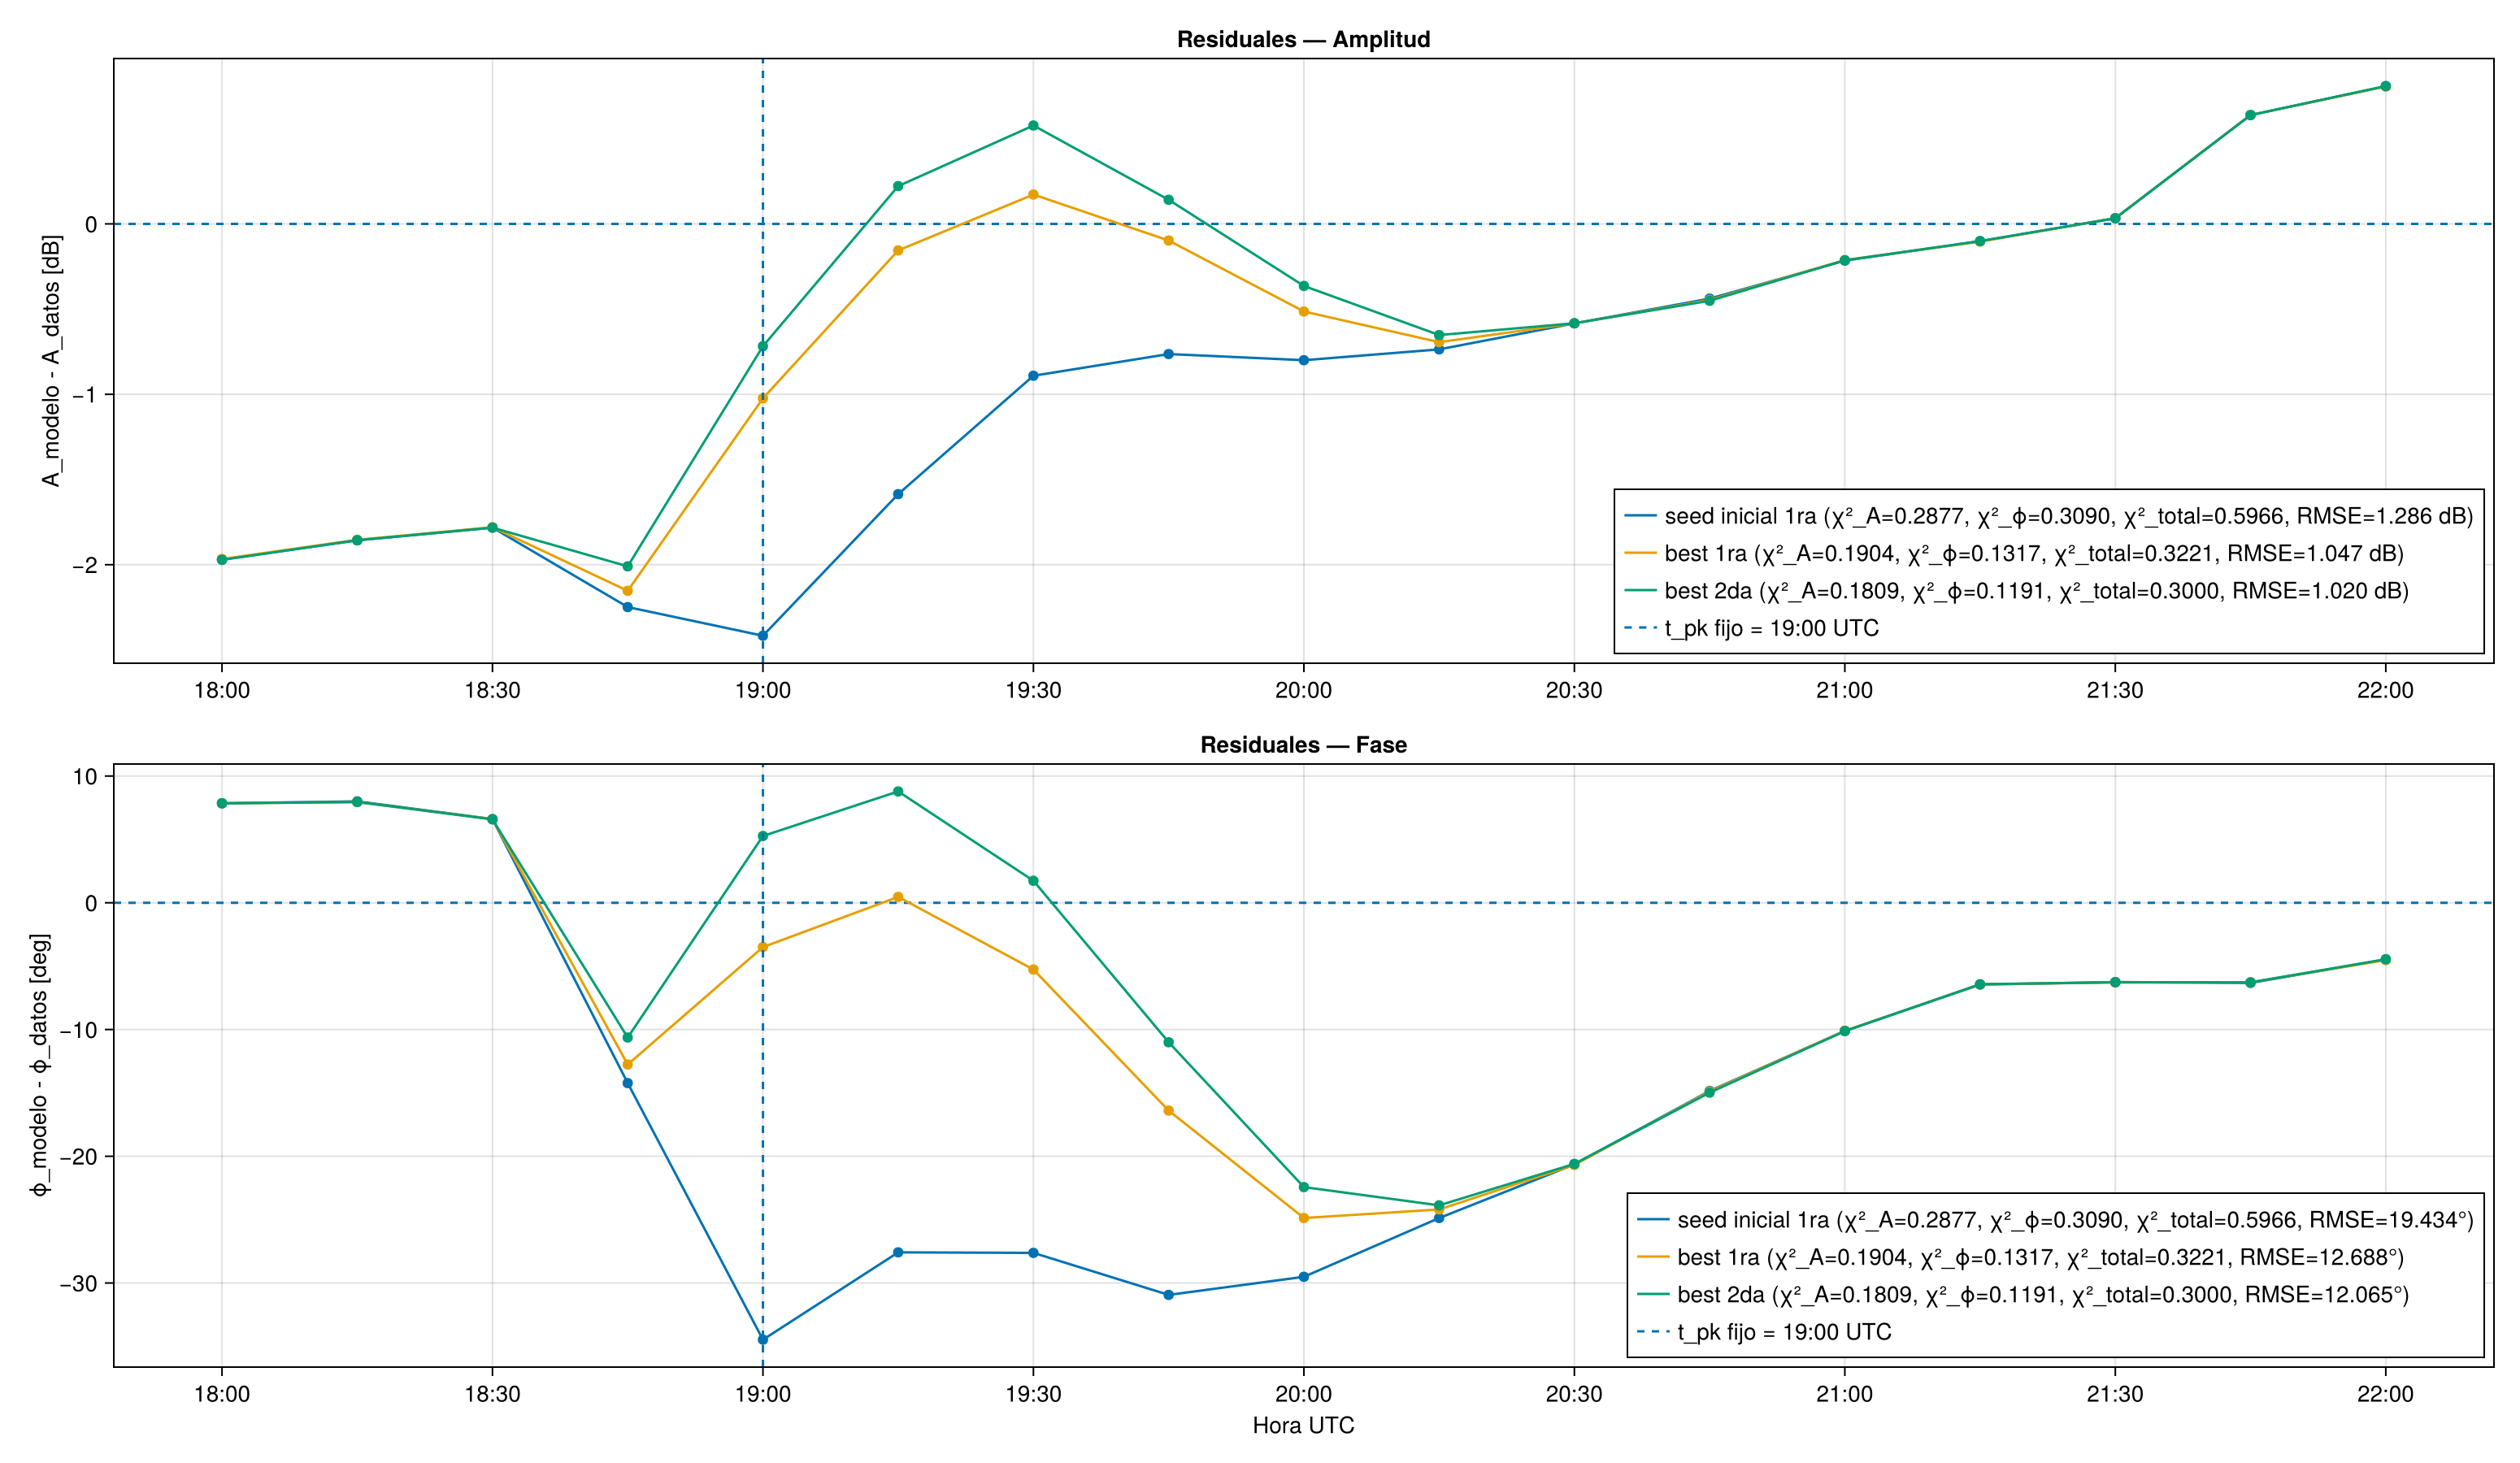

In [16]:
begin
    # ------------------------------------------------------------------------
    # Métricas para armar leyendas manuales con símbolos
    # ------------------------------------------------------------------------
    i_seed1 = findfirst(==("seed inicial 1ra"), metrics.case)
    i_best1 = findfirst(==("best 1ra"), metrics.case)
    i_best2 = findfirst(==("best 2da"), metrics.case)

    i_seed1 === nothing && error("No encontré métricas para seed inicial 1ra")
    i_best1 === nothing && error("No encontré métricas para best 1ra")
    i_best2 === nothing && error("No encontré métricas para best 2da")

    label_seed1_A =
        "seed inicial 1ra " *
        "(χ²_A=$(fmt(metrics[i_seed1, :chi2_norm_A])), " *
        "χ²_ϕ=$(fmt(metrics[i_seed1, :chi2_norm_phi])), " *
        "χ²_total=$(fmt(metrics[i_seed1, :chi2_norm_total])), " *
        "RMSE=$(fmt(metrics[i_seed1, :RMSE_A_dB], digits=3)) dB)"

    label_best1_A =
        "best 1ra " *
        "(χ²_A=$(fmt(metrics[i_best1, :chi2_norm_A])), " *
        "χ²_ϕ=$(fmt(metrics[i_best1, :chi2_norm_phi])), " *
        "χ²_total=$(fmt(metrics[i_best1, :chi2_norm_total])), " *
        "RMSE=$(fmt(metrics[i_best1, :RMSE_A_dB], digits=3)) dB)"

    label_best2_A =
        "best 2da " *
        "(χ²_A=$(fmt(metrics[i_best2, :chi2_norm_A])), " *
        "χ²_ϕ=$(fmt(metrics[i_best2, :chi2_norm_phi])), " *
        "χ²_total=$(fmt(metrics[i_best2, :chi2_norm_total])), " *
        "RMSE=$(fmt(metrics[i_best2, :RMSE_A_dB], digits=3)) dB)"

    label_seed1_phi =
        "seed inicial 1ra " *
        "(χ²_A=$(fmt(metrics[i_seed1, :chi2_norm_A])), " *
        "χ²_ϕ=$(fmt(metrics[i_seed1, :chi2_norm_phi])), " *
        "χ²_total=$(fmt(metrics[i_seed1, :chi2_norm_total])), " *
        "RMSE=$(fmt(metrics[i_seed1, :RMSE_phi_deg], digits=3))°)"

    label_best1_phi =
        "best 1ra " *
        "(χ²_A=$(fmt(metrics[i_best1, :chi2_norm_A])), " *
        "χ²_ϕ=$(fmt(metrics[i_best1, :chi2_norm_phi])), " *
        "χ²_total=$(fmt(metrics[i_best1, :chi2_norm_total])), " *
        "RMSE=$(fmt(metrics[i_best1, :RMSE_phi_deg], digits=3))°)"

    label_best2_phi =
        "best 2da " *
        "(χ²_A=$(fmt(metrics[i_best2, :chi2_norm_A])), " *
        "χ²_ϕ=$(fmt(metrics[i_best2, :chi2_norm_phi])), " *
        "χ²_total=$(fmt(metrics[i_best2, :chi2_norm_total])), " *
        "RMSE=$(fmt(metrics[i_best2, :RMSE_phi_deg], digits=3))°)"

    # ------------------------------------------------------------------------
    # Figura de residuales
    # ------------------------------------------------------------------------
    fig_res = Figure(size = (1550, 900))

    axRA = Axis(
        fig_res[1, 1],
        title = "Residuales — Amplitud",
        ylabel = "A_modelo - A_datos [dB]",
        xticks = xt,
    )

    hlines!(axRA, [0.0], linestyle = :dash)

    lines!(axRA, df.t_min, df.res_A_seed1, label = label_seed1_A)
    scatter!(axRA, df.t_min, df.res_A_seed1)

    lines!(axRA, df.t_min, df.res_A_best1, label = label_best1_A)
    scatter!(axRA, df.t_min, df.res_A_best1)

    lines!(axRA, df.t_min, df.res_A_best2, label = label_best2_A)
    scatter!(axRA, df.t_min, df.res_A_best2)

    vlines!(axRA, [t_pk_plot_min], linestyle = :dash, label = t_pk_label)

    axislegend(
        axRA,
        position = :rb,
        framevisible = true,
        nbanks = 1,
    )

    axRP = Axis(
        fig_res[2, 1],
        title = "Residuales — Fase",
        xlabel = "Hora UTC",
        ylabel = "ϕ_modelo - ϕ_datos [deg]",
        xticks = xt,
    )

    hlines!(axRP, [0.0], linestyle = :dash)

    lines!(axRP, df.t_min, df.res_phi_seed1, label = label_seed1_phi)
    scatter!(axRP, df.t_min, df.res_phi_seed1)

    lines!(axRP, df.t_min, df.res_phi_best1, label = label_best1_phi)
    scatter!(axRP, df.t_min, df.res_phi_best1)

    lines!(axRP, df.t_min, df.res_phi_best2, label = label_best2_phi)
    scatter!(axRP, df.t_min, df.res_phi_best2)

    vlines!(axRP, [t_pk_plot_min], linestyle = :dash, label = t_pk_label)

    axislegend(
        axRP,
        position = :rb,
        framevisible = true,
        nbanks = 1,
    )

    linkxaxes!(axRA, axRP)

    path_res = joinpath(OUTDIR, "residuales_comparacion_seed1_best1_best2.png")
    save(path_res, fig_res)

    println("Figura guardada en: ", path_res)

    fig_res
end


## 10. Comparación visual de métricas


Figura guardada en: /home/jp/basefolder_JP/comparacion_perturbacion_whittaker_restart15572093/metricas_comparacion_seed1_best1_best2.png


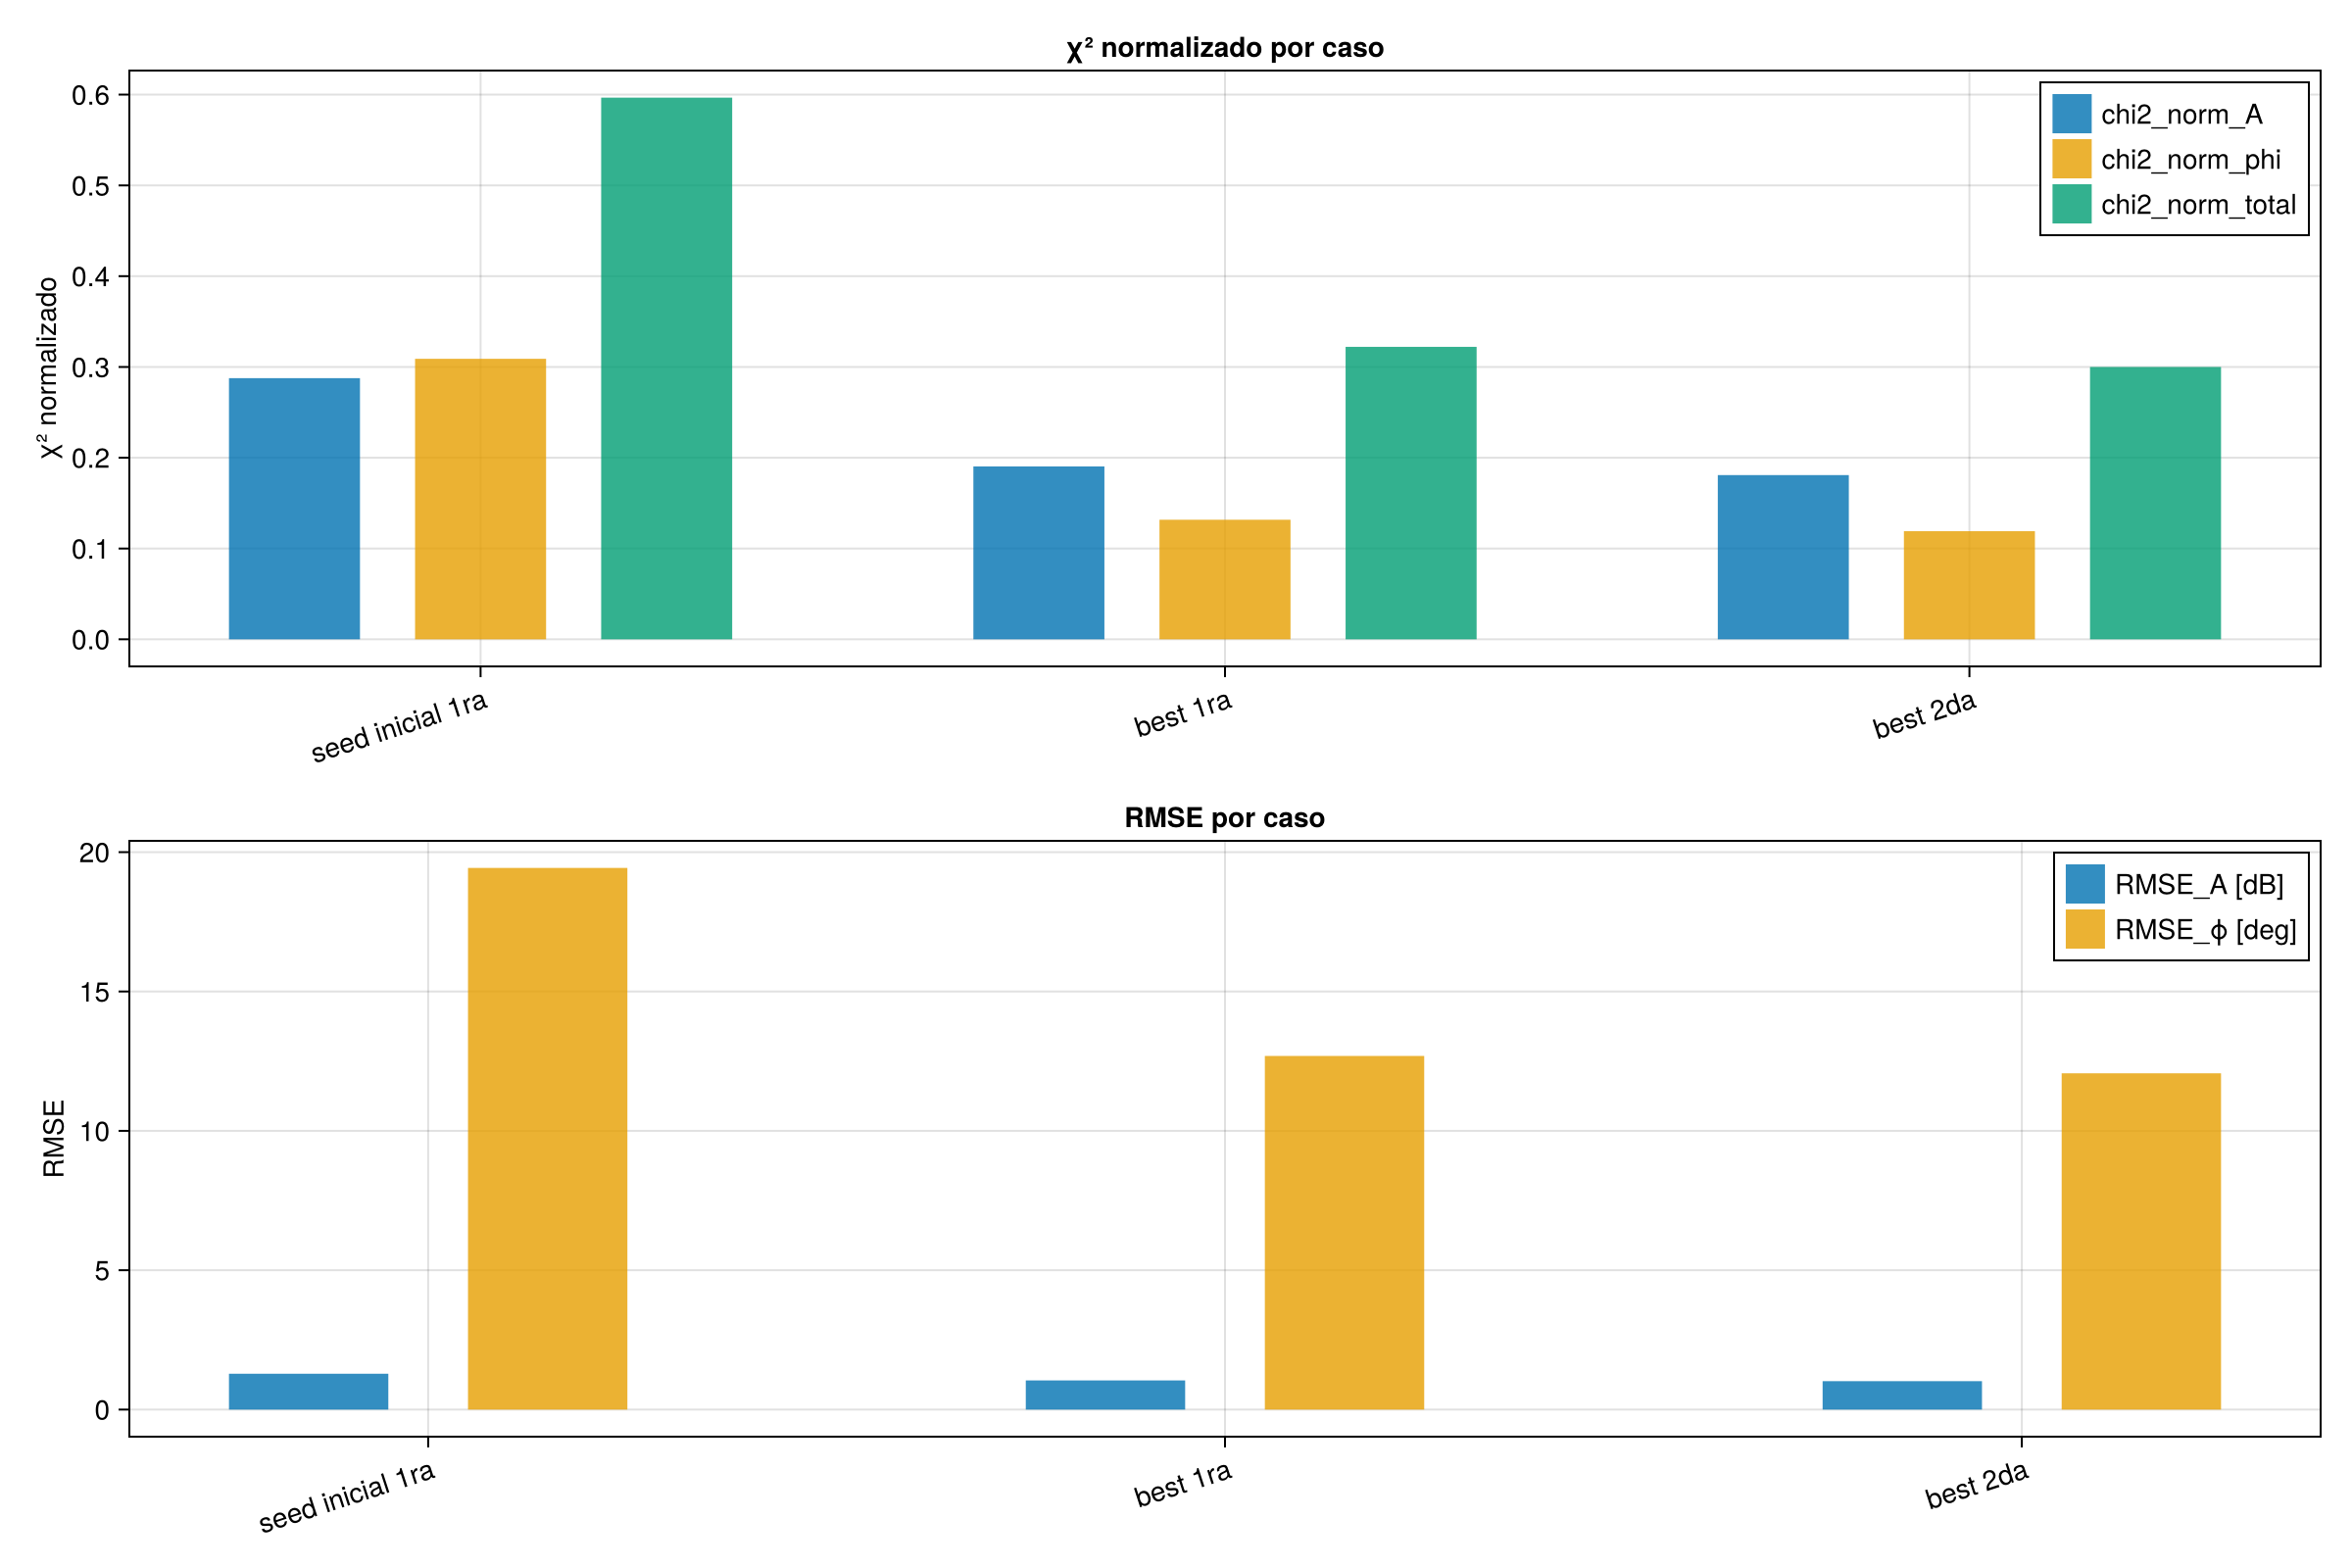

In [11]:

begin
    fig_metrics = Figure(size = (1200, 800))

    x = 1:nrow(metrics)
    labels = metrics.case

    ax1 = Axis(
        fig_metrics[1, 1],
        title = "χ² normalizado por caso",
        ylabel = "χ² normalizado",
        xticks = (collect(x), labels),
        xticklabelrotation = π / 10,
    )

    barplot!(ax1, x .- 0.25, metrics.chi2_norm_A, width = 0.22, label = "chi2_norm_A")
    barplot!(ax1, x, metrics.chi2_norm_phi, width = 0.22, label = "chi2_norm_phi")
    barplot!(ax1, x .+ 0.25, metrics.chi2_norm_total, width = 0.22, label = "chi2_norm_total")
    axislegend(ax1, position = :rt)

    ax2 = Axis(
        fig_metrics[2, 1],
        title = "RMSE por caso",
        ylabel = "RMSE",
        xticks = (collect(x), labels),
        xticklabelrotation = π / 10,
    )

    barplot!(ax2, x .- 0.15, metrics.RMSE_A_dB, width = 0.25, label = "RMSE_A [dB]")
    barplot!(ax2, x .+ 0.15, metrics.RMSE_phi_deg, width = 0.25, label = "RMSE_ϕ [deg]")
    axislegend(ax2, position = :rt)

    path_metrics = joinpath(OUTDIR, "metricas_comparacion_seed1_best1_best2.png")
    save(path_metrics, fig_metrics)
    println("Figura guardada en: ", path_metrics)

    fig_metrics
end



## 11. Comparación de parámetros libres

Parámetros libres:

\[
[\mathrm{amp}, \tau_u, \tau_d, \epsilon, z_0, h_z].
\]


Row,parameter,seed1,best1,best2,delta_best2_vs_best1,rel_delta_best2_vs_best1_pct
,String,Float64,Float64,Float64,Float64,Float64
1,amp,20.0,20.4131,20.5537,0.140531,0.688434
2,tau_u_s,190.578,186.238,192.435,6.19631,3.32709
3,tau_d_s,1248.56,1301.73,1322.16,20.4348,1.56982
4,eps_s,789.685,796.405,818.49,22.0845,2.77303
5,z0_km,85.0,76.6201,74.2477,-2.37244,-3.09637
6,hz_km,10.0,10.1567,9.9598,-0.196916,-1.93878


Figura guardada en: /home/jp/basefolder_JP/comparacion_perturbacion_whittaker_restart15572093/parametros_comparacion_seed1_best1_best2.png


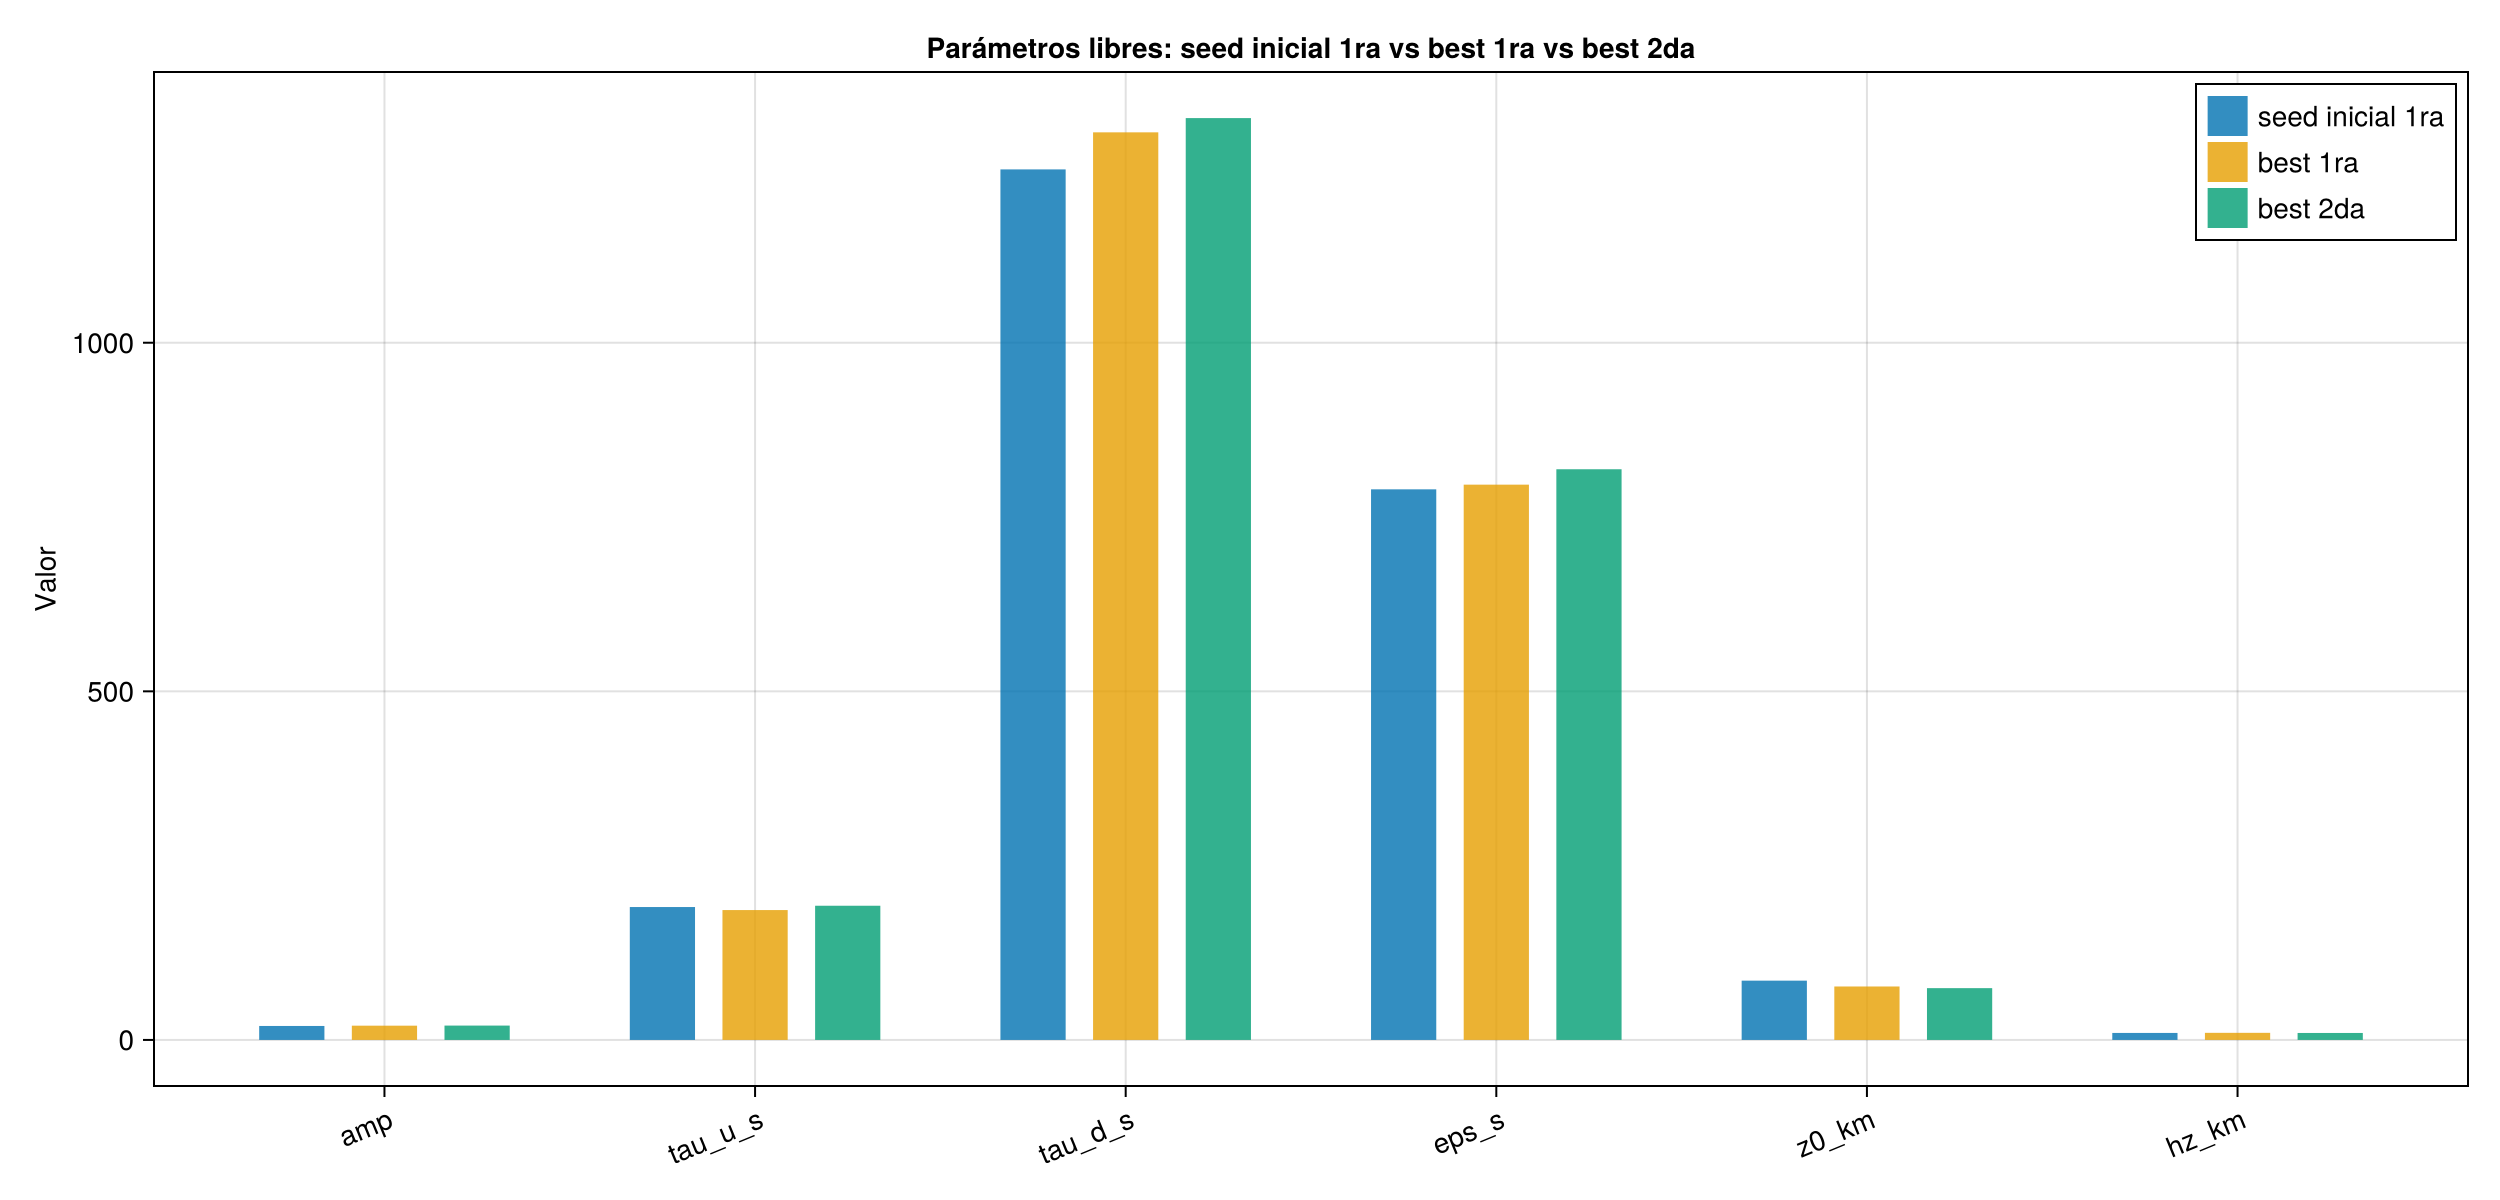

In [12]:

begin
    free_names = ["amp", "tau_u_s", "tau_d_s", "eps_s", "z0_km", "hz_km"]

    params_df = DataFrame(parameter = free_names)
    for c in cases
        params_df[!, Symbol(c.short)] = c.free_params
    end

    params_df.delta_best2_vs_best1 = params_df.best2 .- params_df.best1
    params_df.rel_delta_best2_vs_best1_pct = 100 .* params_df.delta_best2_vs_best1 ./ params_df.best1

    display(params_df)

    fig_params = Figure(size = (1250, 600))
    ax = Axis(
        fig_params[1, 1],
        title = "Parámetros libres: seed inicial 1ra vs best 1ra vs best 2da",
        ylabel = "Valor",
        xticks = (1:length(free_names), free_names),
        xticklabelrotation = π / 8,
    )

    x = collect(1:length(free_names))
    barplot!(ax, x .- 0.25, params_df.seed1, width = 0.22, label = "seed inicial 1ra")
    barplot!(ax, x, params_df.best1, width = 0.22, label = "best 1ra")
    barplot!(ax, x .+ 0.25, params_df.best2, width = 0.22, label = "best 2da")
    axislegend(ax, position = :rt)

    path_params = joinpath(OUTDIR, "parametros_comparacion_seed1_best1_best2.png")
    save(path_params, fig_params)
    println("Figura guardada en: ", path_params)

    fig_params
end



## 12. Exportación de tablas


In [13]:

begin
    # Exporta CSV solo si CSV.jl está disponible.
    try
        @eval using CSV
        CSV.write(joinpath(OUTDIR, "metricas_comparacion_seed1_best1_best2.csv"), metrics)
        CSV.write(joinpath(OUTDIR, "parametros_comparacion_seed1_best1_best2.csv"), params_df)
        CSV.write(joinpath(OUTDIR, "series_residuales_comparacion_seed1_best1_best2.csv"), df)
        println("Tablas CSV exportadas en: ", OUTDIR)
    catch err
        @warn "No pude exportar CSV. Instala CSV.jl si necesitas esta salida." exception=(err, catch_backtrace())
    end
end


Tablas CSV exportadas en: /home/jp/basefolder_JP/comparacion_perturbacion_whittaker_restart15572093
